In [1]:
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from datetime import datetime

from src.plotting.util import load_grids, plot_gdf_column
from src.tides import calc_tide_elevatons

warnings.filterwarnings("ignore")  # hide every warning

In [2]:
BASE = Path("/Users/kyledorman/data/planet_coverage/points_30km/")  # <-- update this
SHORELINES = BASE.parent / "shorelines"

In [3]:
MIN_DIST = 3.0

query_df, grids_df, hex_grid = load_grids(SHORELINES)
valid = ~grids_df.is_land & ~grids_df.dist_km.isna() & (grids_df.dist_km < MIN_DIST) & ~grids_df.tide_range.isna()
grids_df = grids_df[valid].copy()

In [4]:
grids_df.head(3)

,cell_id,dist_km,is_land,is_coast,hex_id,tide_min,tide_max,tide_mean,tide_std,tide_median,...,height_edge_2,height_edge_3,height_edge_4,height_edge_5,height_edge_6,height_edge_7,height_edge_8,height_edge_9,height_edge_10,geometry
grid_id,,,,,,,,,,,,,,,,,,,,,
1051092,2539,2.974694,False,False,4119,-1.130164,0.959492,0.000123,0.387814,0.049735,...,-0.354446,-0.193296,-0.062304,0.049735,0.146444,0.237209,0.340358,0.474721,0.959493,"POLYGON ((-44.80871 -60.8239, -44.73898 -60.77..."
1051093,2539,1.848990,False,False,4119,-1.130164,0.959492,0.000123,0.387814,0.049735,...,-0.354446,-0.193296,-0.062304,0.049735,0.146444,0.237209,0.340358,0.474721,0.959493,"POLYGON ((-44.7064 -60.8239, -44.63683 -60.773..."
1054604,2538,1.318890,False,False,4118,-1.142206,0.957506,0.000124,0.392153,0.051045,...,-0.359455,-0.195197,-0.062554,0.051045,0.148433,0.240541,0.344387,0.478918,0.957507,"POLYGON ((-45.65827 -60.77394, -45.58736 -60.7..."


In [5]:
tide_grid_data = gpd.read_file(BASE.parent / "figs_v2" / "tide_50" / "grid_tide_range" / "data.shp")

tide_grid_data.head(3)

,grid_id,cell_id,dist_km,is_land,is_coast,hex_id,tide_min,tide_max,tide_mean,tide_std,...,height_e_9,height_e10,obs_min_ti,obs_max_ti,sample_cou,obs_tide_r,obs_high_t,obs_low_ti,tide_ran_1,geometry
0,1051092,2539,2.974694,0,0,4119,-1.130164,0.959492,0.000123,0.387814,...,0.474721,0.959493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-44.80871 -60.8239, -44.91101 -60.82..."
1,1051093,2539,1.848990,0,0,4119,-1.130164,0.959492,0.000123,0.387814,...,0.474721,0.959493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-44.7064 -60.8239, -44.80871 -60.823..."
2,1054604,2538,1.318890,0,0,4118,-1.142206,0.957506,0.000124,0.392153,...,0.478918,0.957507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-45.65827 -60.77394, -45.76041 -60.7..."


In [56]:
CA = gpd.read_file(SHORELINES / "la.geojson")
assert CA.crs == tide_grid_data.crs

tide_CA = tide_grid_data[tide_grid_data.intersects(CA.iloc[0].geometry)]

len(tide_grid_data), len(tide_CA)

tide_CA.head(3)

,grid_id,cell_id,dist_km,is_land,is_coast,hex_id,tide_min,tide_max,tide_mean,tide_std,...,height_e_9,height_e10,obs_min_ti,obs_max_ti,sample_cou,obs_tide_r,obs_high_t,obs_low_ti,tide_ran_1,geometry
105904,12627813,31266,1.976452,0,0,29732,-1.310981,1.265954,-0.000282,0.495881,...,0.647033,1.265955,-0.714487,1.112342,81.0,1.826829,0.153612,0.596494,0.708916,"POLYGON ((-117.24534 32.43549, -117.30452 32.4..."
105950,12633893,31267,0.751463,0,0,29732,-1.322510,1.277518,-0.000285,0.499932,...,0.652729,1.277519,-0.714783,1.174758,161.0,1.889542,0.102760,0.607727,0.726739,"POLYGON ((-117.0735 32.48568, -117.13272 32.48..."
105951,12633894,31267,0.000000,0,1,29732,-1.322510,1.277518,-0.000285,0.499932,...,0.652729,1.277519,-0.846464,1.174758,183.0,2.021222,0.102760,0.476046,0.777385,"POLYGON ((-117.01429 32.48568, -117.0735 32.48..."


In [57]:
# tide_CA[["geometry", "tide_ran_1"]].head(2)

import folium
import branca.colormap as cm

gdf = tide_CA

# Create map centered on the data
center = gdf.geometry.centroid.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=8, width=1000, height=800)

key = "tide_ran_1"

# Create a color scale
vmin = gdf[key].min()
vmax = gdf[key].max()

colormap = cm.linear.viridis.scale(vmin, vmax)
colormap.caption = key

# Style function
def style_function(feature):
    val = feature["properties"][key]
    return {
        "fillColor": colormap(val),
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.7,
    }

# Add polygons
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=[key, "grid_id"],
        # aliases=[key],
        localize=True,
    ),
).add_to(m)

# Add color legend
colormap.add_to(m)

m

In [58]:
all_records_df = pd.read_csv("/Users/kyledorman/data/planet_coverage/figs_v2/tide_supplement/all_results.csv")
all_records_df["acquired"] = pd.to_datetime(all_records_df["acquired"], errors="coerce")
all_records_df = all_records_df.sort_values(["grid_id", "acquired"])

filtered_records_df = pd.read_csv("/Users/kyledorman/data/planet_coverage/figs_v2/tide_supplement/filtered_results.csv")
filtered_records_df["acquired"] = pd.to_datetime(filtered_records_df["acquired"], errors="coerce")
filtered_records_df = filtered_records_df.sort_values(["grid_id", "acquired"])

all_records_df["pass_filter"] = False

keys = ["grid_id", "acquired"]

filtered_index = pd.MultiIndex.from_frame(filtered_records_df[keys])
all_index = pd.MultiIndex.from_frame(all_records_df[keys])

all_records_df["pass_filter"] = all_index.isin(filtered_index)

all_records_df.head()

,grid_id,acquired,tide_height,pass_filter
274,12652104,2017-12-01 17:51:49.643824,0.124846,True
273,12652104,2017-12-04 17:51:14.401730,1.096919,False
272,12652104,2017-12-05 17:52:05.025800,1.184010,False
271,12652104,2017-12-06 17:53:02.242803,1.064981,True
269,12652104,2017-12-08 17:53:21.415363,0.407557,False


In [59]:
all_records_df.acquired.min(), all_records_df.acquired.max()

(Timestamp('2017-12-01 17:51:49.643824'),
 Timestamp('2024-11-30 18:58:28.444619'))

In [18]:
low_tide_grid = 12652104
high_tide_grid = 12862252
tide_range_grid = 12903762

start_ts = datetime(year=2017, month=12, day=1)
end_ts = datetime(year=2024, month=12, day=1)

minutes = np.arange(start_ts, end_ts, np.timedelta64(60, "m")).astype("datetime64[ns]")

gdf = tide_CA.set_index("grid_id")

grid_heights = {}

for grid_id in [low_tide_grid, high_tide_grid, tide_range_grid]:
    x = gdf.loc[grid_id].geometry.centroid.x
    y = gdf.loc[grid_id].geometry.centroid.y

    tide_elevations = calc_tide_elevatons(
        ys=np.array([y]),
        xs=np.array([x]),
        ts=minutes,
        model_directory=Path("/Users/kyledorman/data/tides/"),
        model_name="GOT4.10",
        model_format="GOT",
    )[0]

    grid_heights[grid_id] = tide_elevations

In [152]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates


def plot_tide_panel(
    ax,
    grid_id,
    show_bar,
    all_records_df,
    minutes,
    grid_heights,
    start="2017-12-01",
    end="2024-12-01",
    show_legend=False,
    title=None,
):
    """
    Plot one tide panel on a provided axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to draw on.
    grid_id : int
        Grid ID to plot.
    show_bar : {"spread", "low", "high", None}
        Which bracket/annotation to show.
    all_records_df : pd.DataFrame
        DataFrame with columns: grid_id, acquired, tide_height, pass_filter.
    minutes : array-like
        Datetime-like vector aligned to grid_heights[grid_id].
    grid_heights : dict
        Dict mapping grid_id -> tide height array aligned to minutes.
    start, end : str or pd.Timestamp
        Date range to plot.
    show_legend : bool
        Whether to draw legend on this axis.
    title : str or None
        Optional axis title.
    """

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    # ----------------------------
    # 1) Tide time series
    # ----------------------------
    tide_time = pd.to_datetime(minutes)
    tide_height = np.asarray(grid_heights[grid_id])

    tide_df = pd.DataFrame({
        "time": tide_time,
        "tide_height": tide_height,
    })

    tide_df = tide_df[
        (tide_df["time"] >= start) & (tide_df["time"] <= end)
    ].copy()

    # ----------------------------
    # 2) Observation records
    # ----------------------------
    obs = all_records_df.loc[all_records_df["grid_id"] == grid_id].copy()
    obs["acquired"] = pd.to_datetime(obs["acquired"], errors="coerce")
    obs = obs[(obs["acquired"] >= start) & (obs["acquired"] <= end)].copy()

    obs_valid = obs[obs["pass_filter"]].copy()
    obs_invalid = obs[~obs["pass_filter"]].copy()

    # ----------------------------
    # 3) Summary lines
    # ----------------------------
    tide_max = tide_df["tide_height"].max()
    tide_min = tide_df["tide_height"].min()

    obs_max = obs["tide_height"].max()
    obs_min = obs["tide_height"].min()

    # ----------------------------
    # 4) Plot
    # ----------------------------
    ax.plot(
        tide_df["time"],
        tide_df["tide_height"],
        color="#5DA5DA",
        alpha=0.25,
        linewidth=0.8,
        label="Tidal range",
    )

    # Tide limits (dashed)
    ax.axhline(tide_max, color="black", linestyle=(0, (6, 3)), linewidth=1.2)
    ax.axhline(tide_min, color="black", linestyle=(0, (6, 3)), linewidth=1.2)

    # Observed limits (dotted)
    ax.axhline(obs_max, color="black", linestyle=(0, (2, 2)), linewidth=1.2)
    ax.axhline(obs_min, color="black", linestyle=(0, (2, 2)), linewidth=1.2)

    ax.scatter(
        obs_invalid["acquired"],
        obs_invalid["tide_height"],
        s=5,
        c="black",
        alpha=0.75,
        linewidths=0,
        zorder=3,
        label="Invalid observations",
    )

    ax.scatter(
        obs_valid["acquired"],
        obs_valid["tide_height"],
        s=9,
        c="green",
        alpha=0.9,
        linewidths=0,
        zorder=4,
        label="Valid observations",
    )

    # ----------------------------
    # 5) Bracket annotation
    # ----------------------------
    x0 = 1.02
    if show_bar == "spread":
        y0, y1 = obs_min, obs_max
        label = "Spread"
    elif show_bar == "low":
        y0, y1 = tide_min, obs_min
        label = "Low tide offset"
    elif show_bar == "high":
        y0, y1 = obs_max, tide_max
        x0 = 1.03
        label = "High tide offset"
    elif show_bar is None:
        y0 = y1 = label = None
    else:
        raise ValueError("show_bar must be one of {'spread', 'low', 'high', None}")

    if label is not None:
        ax.annotate(
            "",
            xy=(1.01, y1),
            xytext=(1.01, y0),
            xycoords=("axes fraction", "data"),
            arrowprops=dict(
                arrowstyle="|-|",
                lw=1.5,
                color="black",
            ),
        )

        ax.text(
            x0,
            (y0 + y1) / 2,
            label,
            transform=ax.get_yaxis_transform(),
            va="center",
        )

    # ----------------------------
    # 6) Formatting
    # ----------------------------
    ax.set_ylabel("Tide height (m)")
    ax.set_xlabel("")
    ax.set_xlim(tide_df["time"].min(), tide_df["time"].max())
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if title is not None:
        ax.set_title(title)

    if show_legend:
        ax.legend(
            loc="lower center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=3,
            frameon=True,
        )

    return {
        "grid_id": grid_id,
        "tide_max": tide_max,
        "tide_min": tide_min,
        "obs_max": obs_max,
        "obs_min": obs_min,
        "n_valid": len(obs_valid),
        "n_invalid": len(obs_invalid),
    }

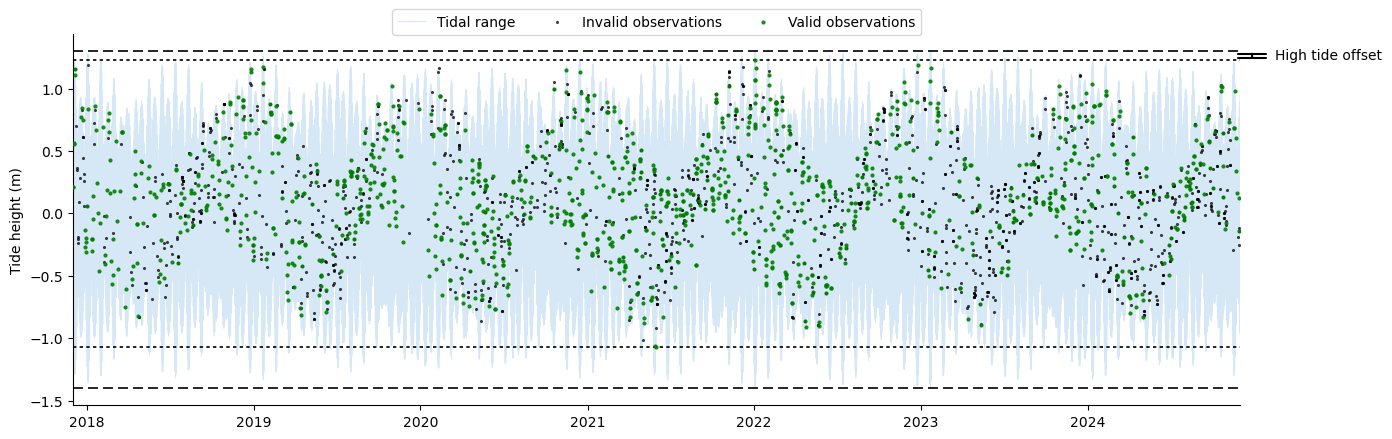

In [153]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4.5))

stats = plot_tide_panel(
    ax=ax,
    grid_id=12862252,
    show_bar="high",
    all_records_df=all_records_df,
    minutes=minutes,
    grid_heights=grid_heights,
    start="2017-12-01",
    end="2024-12-01",
    show_legend=True,
)

plt.tight_layout()
plt.show()

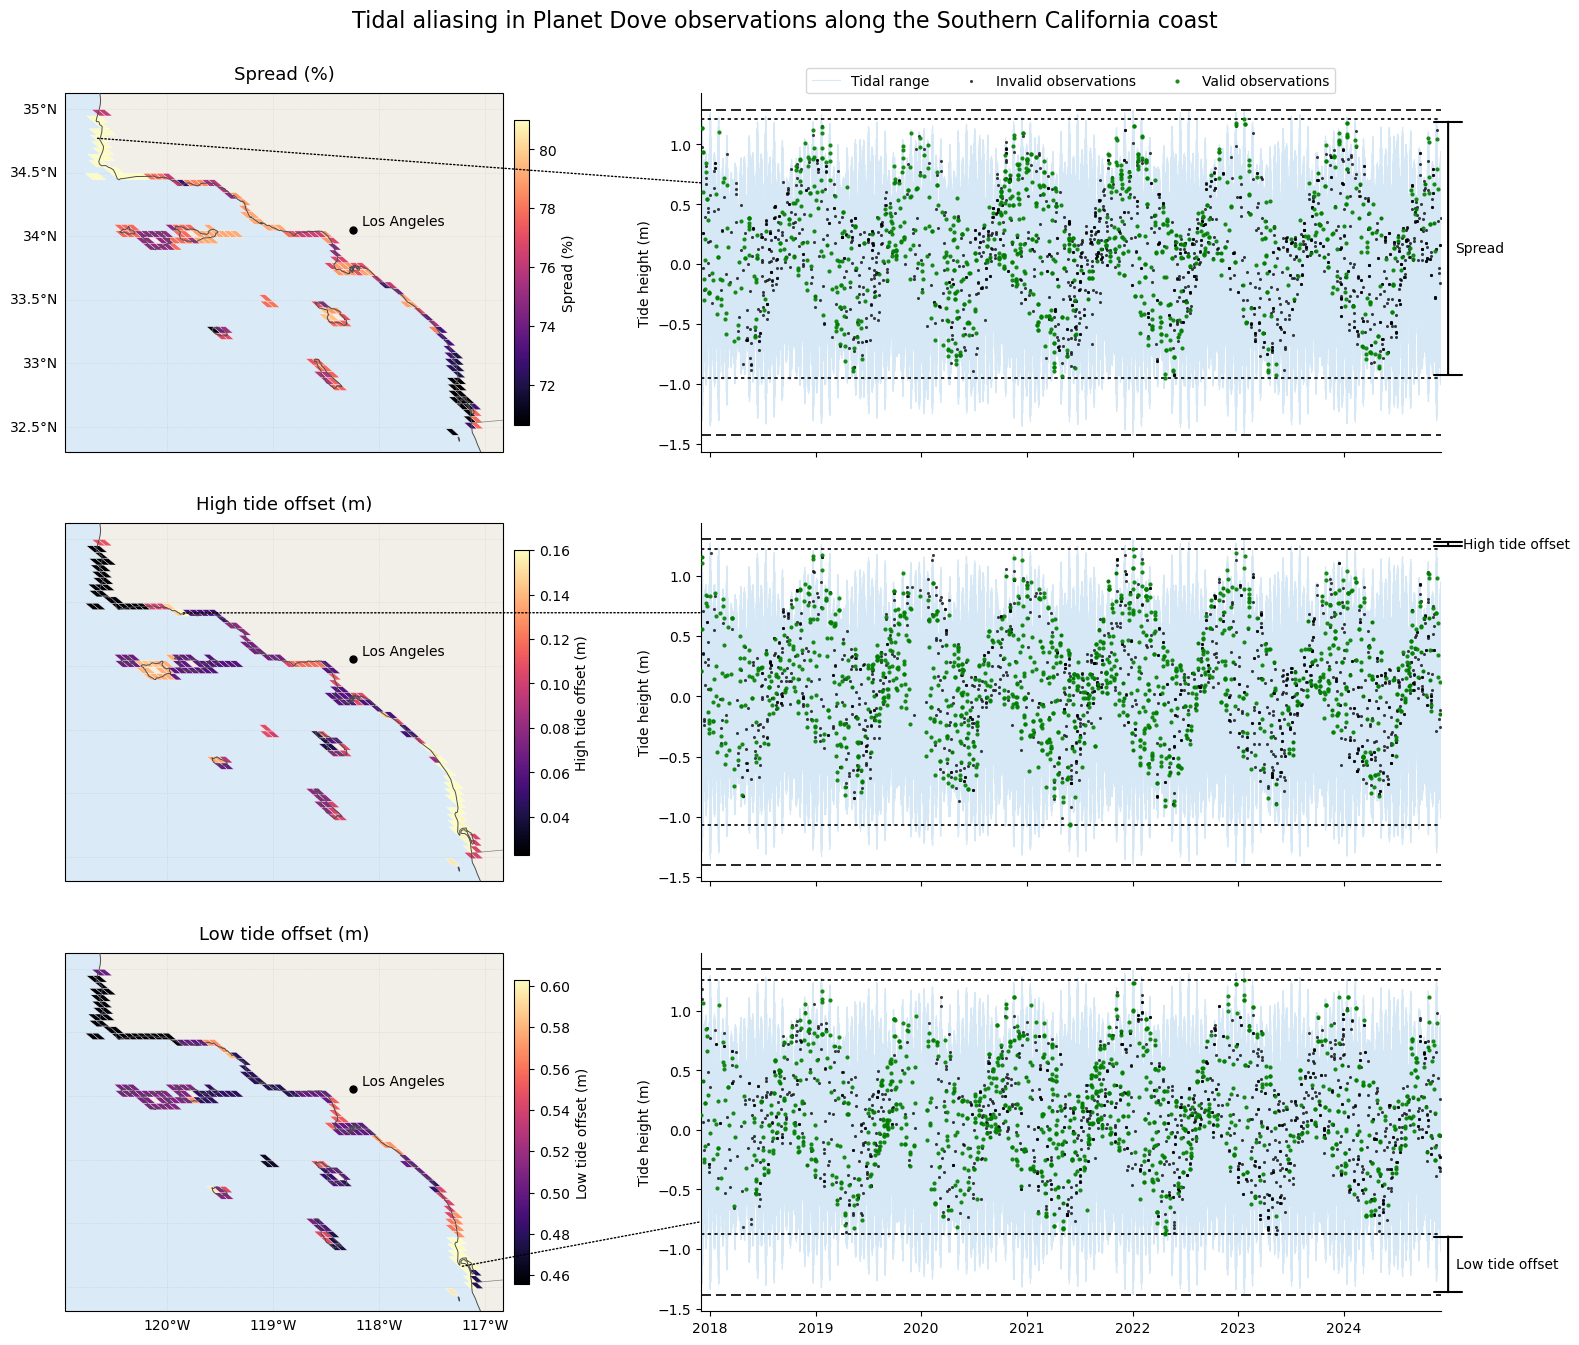

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import ConnectionPatch

# ----------------------------
# 1) Prep
# ----------------------------
gdf = tide_CA.copy()

# Avoid repeated *= 100 if you rerun the cell
if gdf["tide_ran_1"].max() <= 1.5:
    gdf["tide_ran_1"] = gdf["tide_ran_1"] * 100

if gdf.crs is not None and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(4326)

gdf = gdf.dropna(subset=["tide_ran_1", "obs_high_t", "obs_low_ti"], how="all").copy()

xmin, ymin, xmax, ymax = gdf.total_bounds
xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05
extent = [xmin - xpad, xmax + xpad, ymin - ypad, ymax + ypad]

# ----------------------------
# 2) Variable config
# ----------------------------
plot_specs = [
    {
        "col": "tide_ran_1",
        "title": "Spread (%)",
        "cmap": "magma",
        "grid_id": tide_range_grid,
        "show_bar": "spread",
        "line_start_height": 0.75,
    },
    {
        "col": "obs_high_t",
        "title": "High tide offset (m)",
        "cmap": "magma",
        "grid_id": high_tide_grid,
        "show_bar": "high",
        "line_start_height": 0.75,
    },
    {
        "col": "obs_low_ti",
        "title": "Low tide offset (m)",
        "cmap": "magma",
        "grid_id": low_tide_grid,
        "show_bar": "low",
        "line_start_height": 0.25,
    },
]

# ----------------------------
# 3) Helper to draw background
# ----------------------------
def add_base_map(ax, row):
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor="#dbeaf7", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f2efe9", edgecolor="none", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.5", zorder=3)

    la_lon, la_lat = -118.2437, 34.0522
    ax.plot(
        la_lon, la_lat,
        marker="o",
        markersize=5,
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )
    ax.text(
        la_lon + 0.08, la_lat + 0.03,
        "Los Angeles",
        fontsize=10,
        color="black",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="0.6",
        alpha=0.4,
        linestyle=":"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = row == 0
    gl.bottom_labels = row == 2

# ----------------------------
# 4) Build figure with mixed axes
# ----------------------------
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, width_ratios=[1.0, 1.4], wspace=0.17, hspace=0.2)

left_axes = [fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree()) for i in range(3)]
right_axes = [fig.add_subplot(gs[i, 1]) for i in range(3)]

# ----------------------------
# 5) Left column maps
# ----------------------------
for ax, (row, spec) in zip(left_axes, enumerate(plot_specs)):
    col = spec["col"]
    title = spec["title"]
    cmap = spec["cmap"]

    add_base_map(ax, row)

    plot_df = gdf[gdf[col].notna()].copy()

    vmin = plot_df[col].quantile(0.02)
    vmax = plot_df[col].quantile(0.98)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = plot_df[col].min()
        vmax = plot_df[col].max()

    plot_df.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        linewidth=0.25,
        edgecolor="white",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

    ax.set_title(title, fontsize=13, pad=10)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="vertical",
        shrink=0.85,
        pad=0.02,
    )
    cbar.set_label(title)

# ----------------------------
# 6) Right column time-series panels
# ----------------------------
for ax, (row, spec) in zip(right_axes, enumerate(plot_specs)):
    grid_id = spec["grid_id"]
    
    plot_tide_panel(
        ax=ax,
        grid_id=spec["grid_id"],
        show_bar=spec["show_bar"],
        all_records_df=all_records_df,
        minutes=minutes,
        grid_heights=grid_heights,
        start="2017-12-01",
        end="2024-12-01",
        show_legend=row == 0,
    )

    grid_geom = gdf.loc[gdf["grid_id"] == grid_id].geometry.iloc[0]
    centroid = grid_geom.centroid
    
    lon = centroid.x
    lat = centroid.y
    
    con = ConnectionPatch(
        xyA=(lon, lat), coordsA=left_axes[row].transData,
        xyB=(0, spec["line_start_height"]), coordsB=right_axes[row].transAxes,
        linestyle=":",
        linewidth=1,
        color="black"
    )
    fig.add_artist(con)

for ax in right_axes[:-1]:
    ax.tick_params(labelbottom=False)

# Optional: only bottom right gets x label
for ax in right_axes[:-1]:
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelbottom=False)

fig.suptitle(
    "Tidal aliasing in Planet Dove observations along the Southern California coast",
    fontsize=16,
    y=0.98,
)
fig.subplots_adjust(
    left=0.05,
    right=0.91,
    top=0.92,
    bottom=0.05,
    wspace=0.12,
    hspace=0.18,
)
plt.savefig("/Users/kyledorman/data/planet_coverage/figs_v2/tide_supplement/tide_6_pannel.png", dpi=300)
plt.show()